# Jet Engines and High Entropy Alloys
*A Jupyter notebook for teaching the basics of turbofan engine operation, high entropy alloys, and machine learning principles.*

---
## Learning Objectives
By the end, you should be able to:
* Explain the basic mechanisms of turbofan engine operation.
* Describe the material properties that must be considered .
* Use machine learning to predict structures for high entropy alloy development.

---
## Table of Contents
1. Turbofan Physics
2. Material Challenges in the Engine Core
3. High Entropy Alloys
4. Applying AI to HEA Design
5. Activity: Discovering High Entropy Alloys with Gaussian Process Regression


## 1. Turbofan Physics
Turbofan engines are the backbone of modern commercial aviation. If you've flown on a passenger aircraft, chances are, it used a turbofan engine.

Fundamentally, these engines work by taking advantage of Newton's Third Law: they accelerate air backward to push themselves (and the rest of the aircraft) forward. While the principle of operation is simple, the challenge is pushing that air backward as efficiently as possible.

Let's look at how modern turbofan engines accomplish that:

1. Start with jet fuel, a petroleum product that stores energy in hydrocarbons. This energy is released when the fuel is combusted in the engine.
2. Combustion releases a lot of energy in the form of heat, which causes temperature  of air inside the engine to rise. As the Ideal Gas Law describes, increasing temperature of a gas causes pressure and/or volume to increase.
$$PV = nRT$$
$$\uparrow T \quad \therefore \quad \uparrow P,V$$
4. The pressurized, expanding air is directed through a series of turbines that generate electricity for the engine's continued operation.
5. Once the air has imparted some of its energy to the turbines, it rushes out the back of the engine, pushing the engine forward by Newton's Third Law.

From this simplified view of a turbofan engine's operation, we can conclude that increasing the temperature of air is the fundamental process that links potential energy in the form of fuel to kinetic energy used by the aircraft.

However, no engine is perfectly efficient. In fact, even ideal engines are limited by thermodynamics in their ability to turn heat into work. This maximum theoretical efficiency is known as the **Carnot efficiency** and can be illustrated by graphing the **Carnot cycle**.

We'll take a brief detour to show how understanding Carnot cycles can help improve engine efficiency.

<center>
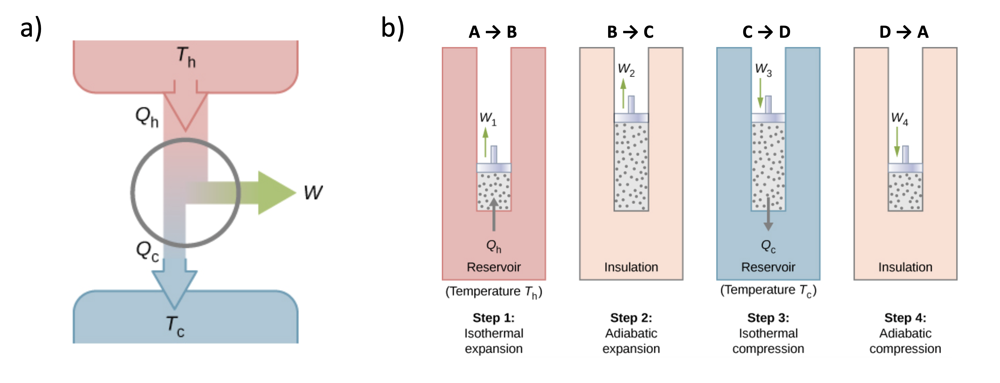
</center>
<figcaption align="center"><b>Figure 1: a) </b> Visual representation of how heat is turned into work by a Carnot engine. Heat from a hot reservoir enters a gas, which performs work, and releases waste heat into a cold reservoir. <b>b)</b> The four steps of the Carnot cycle [1].</figcaption>
<p>

In a Carnot cycle, heat from a hot reservoir enters a gas, which can then perform usable work. Some of the heat is not able to be transformed into work, so it is expelled as heat into a cold reservoir. The ratio of useful work extracted to the amount of heat put in is the Carnot efficiency. 

The following graphs show the relationships between relevant thermodynamic variables, which will later help explain why it is beneficial for aircraft engines to maximize their internal temperature.

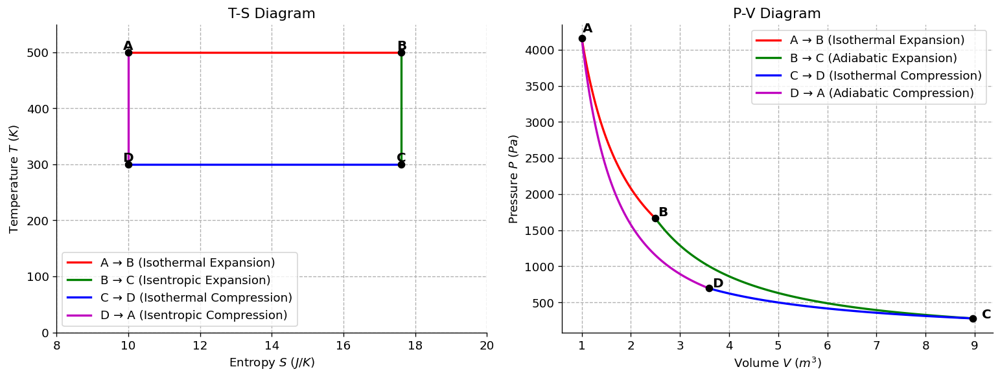

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Define initial cycle parameters
T_H = 500.0    # Hot reservoir temperature (K)
T_C = 300.0    # Cold reservoir temperature (K)
V_A = 1.0      # State A volume (m^3)
V_B = 2.5      # State B volume (m^3) (greater than V_A)
gamma = 7/5    # Ratio of coefficient for a constant volume (C_V) and for a constant pressure process (C_P) of air (source: https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/properties-of-air-text-version/)
nR = 8.314     # Product of mol and ideal gas constant (J/K)

### 2. Calculate volumes at C and D based on thermodynamic relations
vol_ratio = (T_H / T_C) ** (1.0 / (gamma - 1.0))
V_C = V_B * vol_ratio
V_D = V_A * vol_ratio

### 3. Calculate pressures using Ideal Gas Law (P = nRT/V)
P_A = (nR * T_H) / V_A
P_B = (nR * T_H) / V_B
P_C = (nR * T_C) / V_C
P_D = (nR * T_C) / V_D

### 4. Generate 100 data points for each path
# Path 1: Isothermal Expansion (A -> B) at T_H
V_1 = np.linspace(V_A, V_B, 100)
P_1 = (nR * T_H) / V_1

# Path 2: Adiabatic Expansion (B -> C)
V_2 = np.linspace(V_B, V_C, 100)
P_2 = P_B * (V_B / V_2) ** gamma

# Path 3: Isothermal Compression (C -> D) at T_C
V_3 = np.linspace(V_C, V_D, 100)
P_3 = (nR * T_C) / V_3

# Path 4: Adiabatic Compression (D -> A)
V_4 = np.linspace(V_D, V_A, 100)
P_4 = P_D * (V_D / V_4) ** gamma

### 5. Define true Entropy changes for the T-S Diagram
S_A = 10.0     # Arbitrary positive value to make graph look nice
S_B = S_A + nR * np.log(V_B / V_A)
S_C = S_B  
S_D = S_A  

# Generate 100 points for each T-S path
S_1 = np.linspace(S_A, S_B, 100)
T_1 = np.full_like(S_1, T_H)

S_2 = np.full_like(np.linspace(T_H, T_C, 100), S_B)
T_2 = np.linspace(T_H, T_C, 100)

S_3 = np.linspace(S_C, S_D, 100)
T_3 = np.full_like(S_3, T_C)

S_4 = np.full_like(np.linspace(T_C, T_H, 100), S_D)
T_4 = np.linspace(T_C, T_H, 100)

### 6. Plot T-S (rectangle shaped) and P-V (sickle shaped) graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Temperature-Entropy (T-S) Carnot Cycle
ax1.plot(S_1, T_1, 'r-', label='A → B (Isothermal Expansion)', linewidth=2)
ax1.plot(S_2, T_2, 'g-', label='B → C (Isentropic Expansion)', linewidth=2)
ax1.plot(S_3, T_3, 'b-', label='C → D (Isothermal Compression)', linewidth=2)
ax1.plot(S_4, T_4, 'm-', label='D → A (Isentropic Compression)', linewidth=2)
ax1.set_ylim(top=550)
ax1.set_ylim(bottom=0)
ax1.set_xlim(left=8)
ax1.set_xlim(right=20)

# Label the states on T-S
for state, s, t in zip(['A', 'B', 'C', 'D'], [S_A, S_B, S_C, S_D], [T_H, T_H, T_C, T_C]):
    ax1.plot(s, t, 'ko')
    ax1.text(s, t + 5, state, fontsize=12, fontweight='bold', ha='center')

ax1.set_title('T-S Diagram')
ax1.set_xlabel('Entropy $S$ ($J/K$)')
ax1.set_ylabel('Temperature $T$ ($K$)')
ax1.grid(True, linestyle='--')
ax1.legend()

# Plot 2: Pressure-Volume (P-V) Carnot Cycle
ax2.plot(V_1, P_1, 'r-', label='A → B (Isothermal Expansion)', linewidth=2)
ax2.plot(V_2, P_2, 'g-', label='B → C (Adiabatic Expansion)', linewidth=2)
ax2.plot(V_3, P_3, 'b-', label='C → D (Isothermal Compression)', linewidth=2)
ax2.plot(V_4, P_4, 'm-', label='D → A (Adiabatic Compression)', linewidth=2)

# Label the states on P-V
for state, v, p in zip(['A', 'B', 'C', 'D'], [V_A, V_B, V_C, V_D], [P_A, P_B, P_C, P_D]):
    ax2.plot(v, p, 'ko')
    ax2.text(v * 1.02, p * 1.02, state, fontsize=12, fontweight='bold')

ax2.set_title('P-V Diagram')
ax2.set_xlabel('Volume $V$ ($m^3$)')
ax2.set_ylabel('Pressure $P$ ($Pa$)')
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()


In both graphs, the area enclosed by the cycle gives an indication of the amount of useful work this ideal engine can generate. It is simpler to consider the temperature-entropy graph on the left, so we will look more closely at it now.

The area inside the temperature-entropy graph represents the net heat energy that has been converted into work. This fact can be understood if we look more closely at what each step in the cycle is doing.
1. As the gas moves from A to B isothermally, entropy (and volume) goes up but temperature remains constant. Therefore, the area under this line represents heat absorbed by the gas from the hot reservoir, denoted by $Q_{in}$.
2. The area under the step from B to C is zero, so we can ignore it for now.
3. However, the step from C to D is the opposite of step A-B; temperature remains constant, but the gas is compressed, so it must release heat into the cold reservoir, denoted by $Q_{out}$.
4. Like the B-C step, movement from D to A contributes zero area, so it can be ignored for the calculation of work.

Graphing the input heat and red and the waste heat as blue, we get the following:

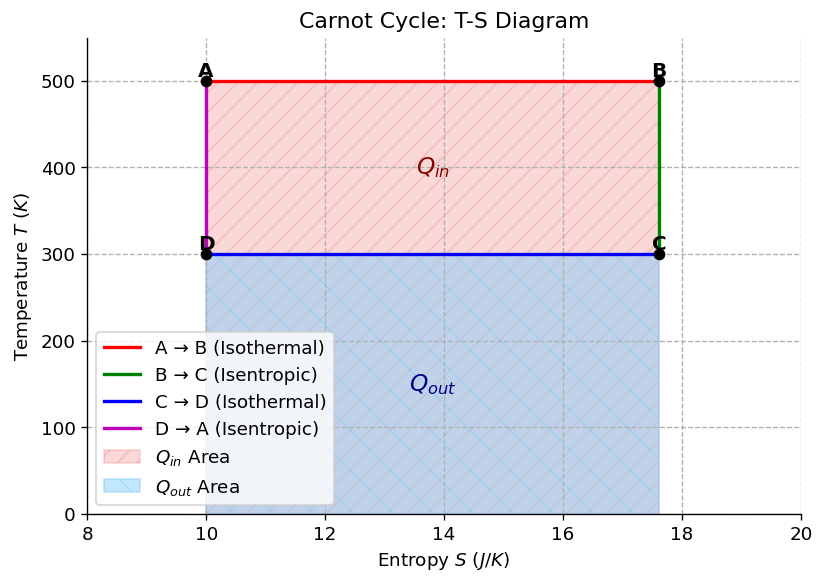

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define independent cycle parameters
T_H = 500.0    # Hot reservoir temperature (K)
T_C = 300.0    # Cold reservoir temperature (K)
V_A = 1.0      # State A volume (m^3)
V_B = 2.5      # State B volume (m^3) - must be > V_A
nR = 8.314     # Product of moles and gas constant (J/K)

# 2. Define true Entropy changes for the T-S Diagram
S_A = 10.0
S_B = S_A + nR * np.log(V_B / V_A)
S_C = S_B  
S_D = S_A  

# 3. Generate continuous data points for each path
S_1 = np.linspace(S_A, S_B, 100)
T_1 = np.full_like(S_1, T_H)

S_2 = np.full_like(np.linspace(T_H, T_C, 100), S_B)
T_2 = np.linspace(T_H, T_C, 100)

S_3 = np.linspace(S_C, S_D, 100)
T_3 = np.full_like(S_3, T_C)

S_4 = np.full_like(np.linspace(T_C, T_H, 100), S_D)
T_4 = np.linspace(T_C, T_H, 100)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot paths
ax1.plot(S_1, T_1, 'r-', label='A → B (Isothermal)', linewidth=2)
ax1.plot(S_2, T_2, 'g-', label='B → C (Isentropic)', linewidth=2)
ax1.plot(S_3, T_3, 'b-', label='C → D (Isothermal)', linewidth=2)
ax1.plot(S_4, T_4, 'm-', label='D → A (Isentropic)', linewidth=2)

# Shading regions
ax1.fill_between(S_1, 0, T_1, color='lightcoral', alpha=0.3, label='$Q_{in}$ Area', hatch='//')
ax1.fill_between(S_1, 0, T_C, color='lightskyblue', alpha=0.5, label='$Q_{out}$ Area', hatch='\\')

# Shading text annotations
s_center = (S_A + S_B) / 2
ax1.text(s_center, (T_H + T_C) / 2, '$Q_{in}$', fontsize=14, fontweight='bold', ha='center', va='center', color='darkred')
ax1.text(s_center, T_C / 2, '$Q_{out}$', fontsize=14, fontweight='bold', ha='center', va='center', color='darkblue')

# Label state vertices (A, B, C, D)
for state, s, t in zip(['A', 'B', 'C', 'D'], [S_A, S_B, S_C, S_D], [T_H, T_H, T_C, T_C]):
    ax1.plot(s, t, 'ko')
    ax1.text(s, t + 5, state, fontsize=12, fontweight='bold', ha='center')

# Graph configuration
ax1.set_title('Carnot Cycle: T-S Diagram')
ax1.set_xlabel('Entropy $S$ ($J/K$)')
ax1.set_ylabel('Temperature $T$ ($K$)')
ax1.set_ylim(bottom=0)  
ax1.grid(True, linestyle='--')
ax1.set_ylim(top=550)
ax1.set_ylim(bottom=0)
ax1.set_xlim(left=8)
ax1.set_xlim(right=20)

# Moved the legend position here
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()


The difference between $Q_{in}$ and $Q_{out}$, represented by the area shaded in red but not blue, is the heat drawn into the engine that is not later expelled as waste heat; since energy cannot be created nor destroyed, **that heat energy has been converted into work**.

Another observation we can make is that we can increase this area in two ways: decreasing the cold temperature (lowering the blue line to decrease the amount subtracted from the red area) or increasing the hot temperature (raising the red line to add more red area).

Mathematically, this idea can be expressed by the engine efficiency, $\eta$. Recall that Carnot efficiency is the ratio of useful work extracted to the amount of heat put in.
$$\eta = \frac{W}{Q_{in}}$$

Also recall that useful work is the difference $Q_{in} - Q_{out}$
$$\eta = \frac{Q_{in} - Q_{out}}{Q_{in}}$$

In terms of absolute temperature (K), this can be written as:
$$\boxed{\eta = \frac{T_{hot} - T_{cold}}{T_{hot}} = 1- \frac{T_{cold}}{T_{hot}}}$$

Therefore, the **efficiency** of engines which can be modeled by the Carnot cycle, such as turbofan aircraft engines, ultimately **depends on the achievable temperature difference**.

### Bringing it all together:
* <span style="font-size: 120%;">Turbofan engines fundamentally work by heating up air to extract work.</font>
* <span style="font-size: 120%;">This can be modeled by a Carnot cycle, which presents the most ideal case.</font>
* <span style="font-size: 120%;">The efficiency of a Carnot engine can be increased by either decreasing the temperature of the cold reservoir or increasing the temperature of the hot reservoir.</font>
* <span style="font-size: 120%;">Aircraft cannot change the temperature of their surrounding air, so to increase efficiency, they must increase their internal temperature.</font>


## 2. Material Challenges in the Engine Core
In order to maximize efficiency, modern turbofan engines operate around 1500°C, which is well above the melting points of most metals. For example, aluminum melts at 660°C, copper at 1085°C, and iron at 1538°C [2]; as you may be able to guess, an engine's components melting into liquid is incompatible with operation. However, even if the temperature does not exceed a metal's melting point, extreme heat poses significant challenges to operation.

### Challenge 1: Mechanical
Even well below a metal's melting point, elevated temperatures can cause mechanical weakening due to a process known as creep.

All real metals have internal defects, including vacancies, dislocations, and grain boundaries. Under a constant load (e.g. self-weight, supporting a structure, or centrifugal force) and in an environment with enough ambient thermal energy, these defects will move to relieve that internal stress. The movement of these microscopic defects can contribute to macroscale deformation.

<center>
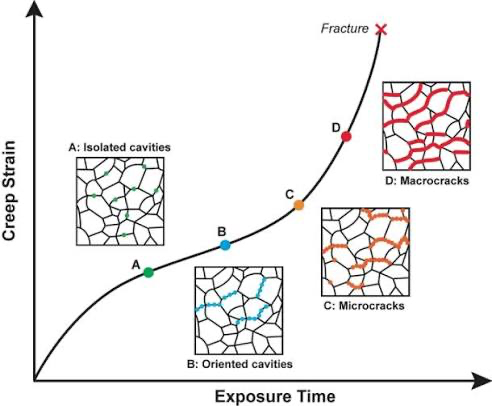
</center>
<figcaption align="center"><b>Figure 2:</b> Stress-induced strain over time characteristic of creep. Under constant stress, defects gradually move and coalesce until they cause macroscale deformation [3].</figcaption>
<p>

The slow sagging of a structural beam, a glacier flowing down a mountain under its own weight, and the warpage of a spinning turbine blade under centrifugal force are all examples of creep.

In turbofan engines, on top of the dangers of a diminished ability to carry loads, creep also presents a problem due to the tight tolerances built into the engine. In a tightly engineered engine core, small deformations can cause grinding, wear, or render the engine completely nonfunctional.

### Challenge 2: Chemical
High temperatures can also chemically weaken metals by accelerating the diffusion of reactive species into the material. Recall that the diffusion coefficient is governed by an Arrhenius relationship:

$$D = D_0 e^{\frac{-Q_d}{RT}}$$

Where $D$ is the diffusion coefficient at a given temperature, $D_0$ is the preexponential, $Q_d$ is the activation energy, $R$ is the gas constant, and $T$ is the absolute temperature. As temperature increases, so does the diffusion coefficient.

In a combustion environment, such as a turbofan engine, major reactive species include oxygen and hydrogen. At elevated temperatures, these species can diffuse much more quickly, leading to unwanted effects.

Oxygen reacts with the metal itself, producing metal oxides that may form a rust-like scale on the surface of parts. Hydrogen, due to its small size, can penetrate the crystal lattice build up inside the metal, where it hinders dislocation and grain boundary mobility. In moderation, this mechanism can strength a metal, but unchecked, it causes embrittlement, increasing the likelihood that a small defect will lead to catastrophic failure.

<center>
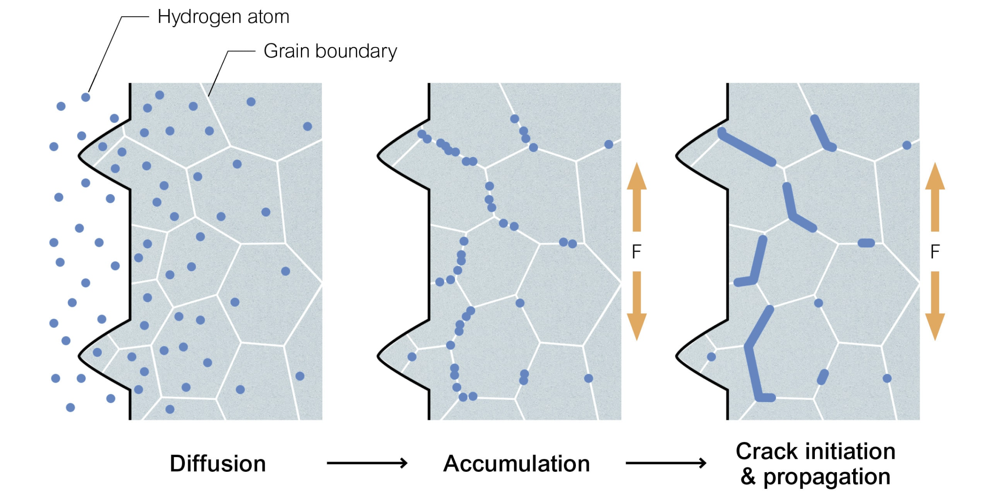
</center>
<figcaption align="center"><b>Figure 3:</b> Mechanism for hydrogen embrittlement. In an embrittled material, even small defects can cause catastrophic failure, leading to a material that fails well below its ultimate tensile strength [4].</figcaption>
<p>

In turbofan engines, elevated temperatures lead to accelerated diffusion and increased risk of irreversible damage.

### Mitigation Strategies
To counteract the mechanical and chemical challenges of high temperature operations, engineers employ a number of strategies.

Modern turbofan engine cores take advantage of nickel-based superalloys, such as Inconel 718. Due to their composition, these alloys have melting points well above those of most metals. More than that, however, their microstructure is engineered to retain mechanical strength by resisting dislocation motion and grain boundary sliding. These superalloys undergo an aging treatment that results in the formation of $\gamma$' and $\gamma$" precipitates that physically disrupt movement of defects, thereby hindering creep mechanisms [5].

In addition, the components exposed to the highest temperatures within the engine are protected by thermal barrier coatings: ceramics with melting points much higher than the melting point of the bulk alloy. The ceramic acts as both an obstacle to heat transfer, protecting the alloy from being exposed to the most extreme temperatures, and as a physical barrier to prevent corrosive species from diffusing into the metal [6].

Finally, the physical design of parts themselves can facilitate high temperature operations. The blades in turbofan engines contain channels that allow air to penetrate and cool their internal structures.

<center>
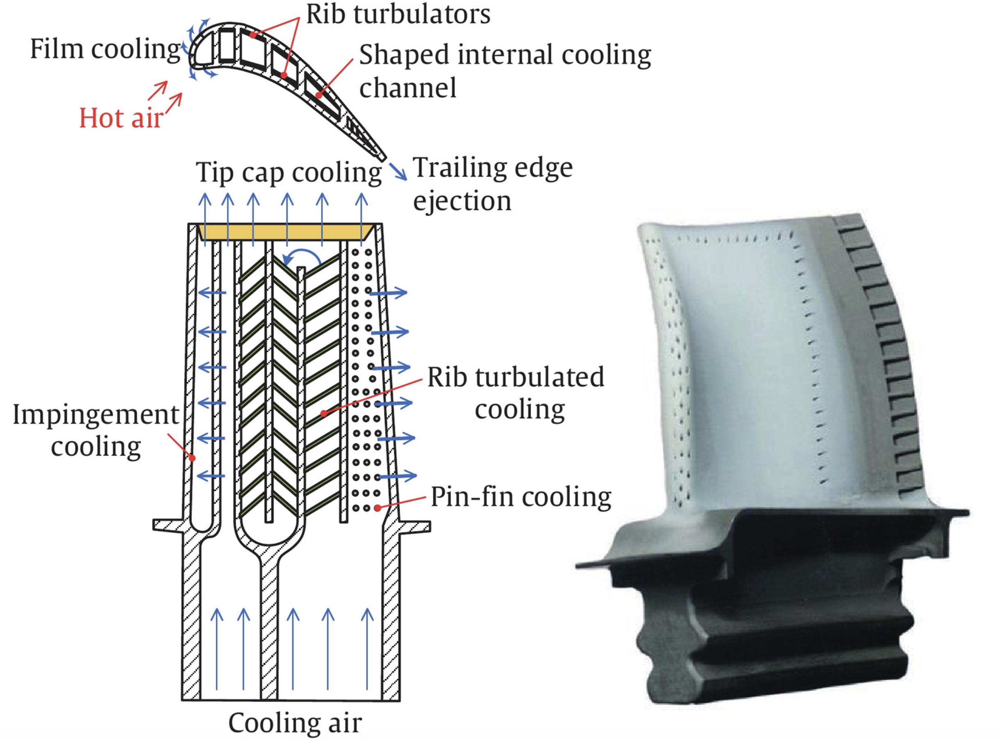
</center>
<figcaption align="center"><b>Figure 4:</b> Cross section of a a turbofan engine turbine blade, including the internal structure of the blade, which allows air to flow in and cool the metal [7].</figcaption>
<p>

However, strategies such as microstructure engineering, thermal barrier coatings, and mechanical part design can only go so far in protecting metals in the engine core from extreme temperatures. At some point, better materials are needed.


## 3. High Entropy Alloys
As mentioned, current turbofan engines take advantage of nickel-based superalloys, such as Inconel 718, to withstand extreme operating conditions. These alloys have excellent combinations of mechanical strength, high melting points, corrosion resistance, and relatively low density, and their compositions have been meticulously engineered to achieve this combination of properties.

For example, the composition of Inconel 718 is as follows:

<center><em>Table 1: Elemental Composition of Inconel 718 [5]</center>
<center>
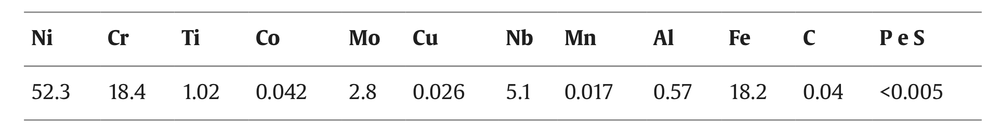
</center>

While this material performs incredibly well up to temperatures of 650-700°C, the continual drive to improve engine efficiency demands ever higher melting points without sacrificing other advantageous properties.

One recent avenue of interest for designing new alloys with enhanced combinations of properties is **high entropy alloys** (HEAs). Where most conventional alloys have one to three principal components, HEAs have at least five elements in roughly equal proportions. This large number of components leads to high configurational entropy, or a large number of unique ways to arrange distinct atoms within the material [8].

<center>
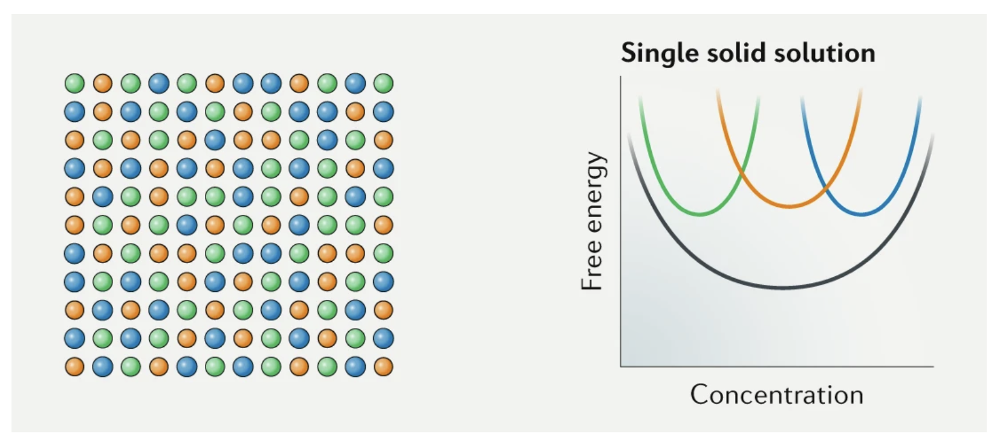
</center>
<figcaption align="center"><b>Figure 5:</b> In a high entropy alloy, the high configurational entropy (represented by the random distribution of green, blue, and orange atoms in the diagram) results in a lower Gibbs free energy for the alloy compared to any individual component [8].</figcaption>
<p>

To explain why high configurational entropy is advantageous, recall that Gibbs free energy governs the stability of a material. When a change in Gibbs free energy ($\Delta G$) is negative, the product material is more stable than its individual components. Also recall that Gibbs free energy is a function of enthalpy ($\Delta H$) and entropy ($\Delta S$).

$$\Delta G = \Delta H - T\Delta S$$

When entropy is high, Gibbs free energy can be negative even if the enthalpy of formation is also high. In terms of HEAs, this means that they are more stable as a single phase solid solution than any of their components are as pure materials. This makes the solid solution highly resistant to physical or chemical degradation, preventing the formation of precipitate phases that may weaken and embrittle other alloys [8].

The thermodynamic stability of HEAs, alongside their incorporation of multiple elements in large proportions, yields advantageous and often surprising combinations of properties. By incorporating multiple components with desired properties, high entropy alloys can allow engineers to optimize several properties simultaneously, such as toughness, yield strength and melting point [8].

Despite the vast potential of HEAs, current development of these materials faces several challenges. Chief among them is the extremely large compositional space available for exploration. By their very nature, HEAs make use of many elements within their structures; even limiting the pool of candidate elements to ten, there are thousands of ways to combine those ten elements in varying proportions, and it is infeasible to experimentally synthesize and characterize them all in a timely manner.

However, artificial intelligence and machine learning (AI/ML) provides a powerful tool to tackle this particular challenge. AI/ML techniques can help sift through vast amounts of data to identify trends and narrow the focus of experimental researchers towards compositions that are more likely to yield results. In this way, AI/ML has the potential to greatly accelerate the development of novel high entropy alloys tailored to specific applications, such as turbofan engines.


## 4. Applying AI to HEA Design
AI/ML techniques span a wide range of capabilities, but some methods are more suited for certain applications. In general, AI/ML methods can be described as **supervised learning** or **unsupervised learning**.

In **supervised learning**, the operator labels training data with known inputs and outputs. The machine then learns the relationships between inputs and outputs, and is therefore able to make predictions about new data [9]. In a simple example, when given a list of densities and their corresponding material class (e.g. metals, ceramics, polymers), a machine can learn that polymers generally have low density, and it can classify new data based on that rule of thumb.

In **unsupervised learning**, the operator does give the machine a definite list of corresponding inputs and outputs, but asks the machine to group the data into the clusters it thinks best fit underlying patterns [9]. In other words, the operator does not give the machine an "answer key" to which items fit in which categories, or even what categories exist or how many there are. This approach can allow the machine to more freely discover associations that may not be obvious to the operator. Returning to the density and material class example, an unsupervised algorithm may discover that the data best fits into three categories that map onto metals, ceramics, and polymers, or it may discover that the data better fits into four categories that map onto light metals, heavy metals, ceramics, polymers.

This activity will focus on a form of **supervised learning** known as **Gaussian Process Regression** (GPR).

<center>
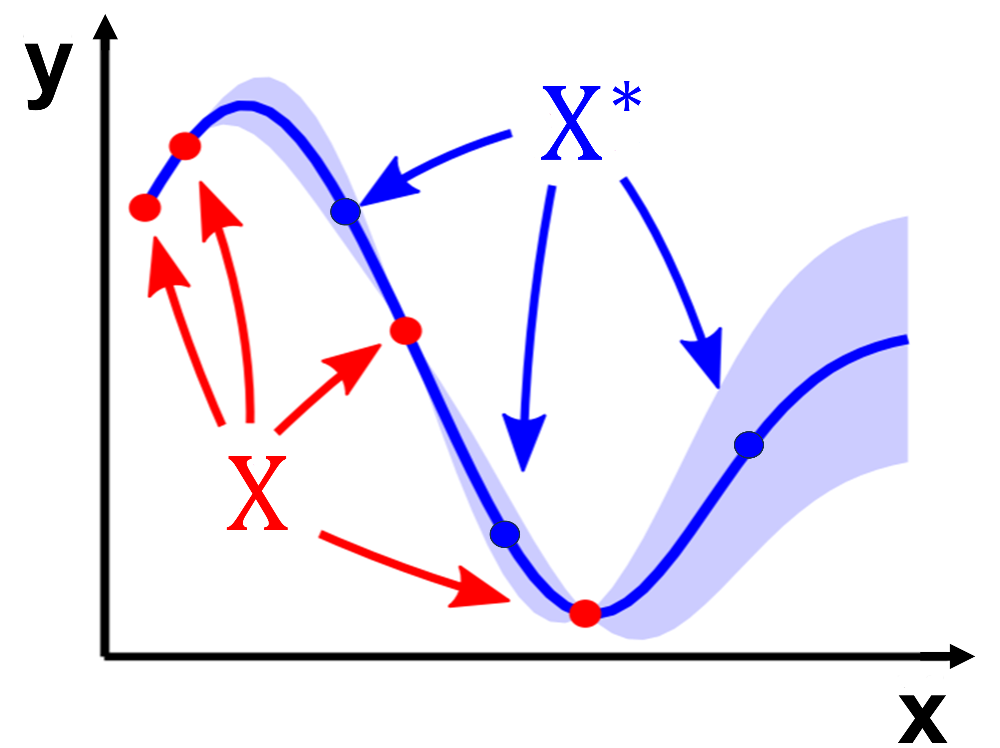
</center>
<figcaption align="center"><b>Figure 6:</b> Simplified schematic of how GPR works. Red points (X) are observed data, the blue line represents the mean function estimated by the GPR, and blue points (X*) are specific predicted outputs at given input values. [10].</figcaption>
<p>

At its core, GPR uses an algorithm to generate a function that fits given data, a function for which it provides an indication of uncertainty. This function can then be used to make predictions about new data [10]. A significant advantage of this method is that it can make predictions about complex, multivariate systems in a computationally inexpensive way by using kernels, or covariance functions.

Kernels are mathematical relationships used to describe the degree of similarity between two data points. Usually, to describe similarity between points in a multivariable dataset, the algorithm would have to map data into a higher dimensional space, but with a "kernel trick" (yes, this is the technical term), this can be accomplished without calculating these higher dimensions directly [10]. Thus, using kernels massively saves on computational power and makes GPR possible on ordinary consumer computers.

There are many different types of kernels for different applications depending on the expected function behavior, but the Radial Basis Function kernel [10], shown below, is used across domains.

$$k(x_i, x_j) = \sigma^2 \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\ell^2}\right)$$

Where $\sigma^2$ is a contant coefficient, $\|x_i - x_j\|^2$ is the Euclidean distance between points $x_i$ and $x_j$, and $l$ is a lengthscale parameter. This kernel is used to construct smooth, continuous curves, leading to differentiable model predictions.

Pulling it all together, GPR uses known data and some computational tricks to draw a series of best fit functions connecting existing points. The mean function provides the overall regression line, which can be used to make predictions, and the envelope surrounding this regression line provides a confidence interval with which to contextualize the results.

### Pre-Activity
The capabilities of AI/ML can be leveraged to determine which materials, or even hypothetical substances, have potential in auxetic designs. **However, understanding the materials science behind the problem is critical before handing the data over to a computer.**

Consider the variables of this design challenge:
1. **Composition:** This is the independent variable. By tuning composition, we aim to create high entropy alloy that exhibits a combination of thermal stability and mechanical strength.
2. **Melting Point:** This is a dependent variable, one of the metrics of success. We aim to maximize melting point without sacrificing mechanical properties.
3. **Yield Strength:** This is another dependent variable, one measure of an alloy's mechanical strength.

With this knowledge, we can put together a dataset to train an AI/ML model. From Granta, we create a table of existing superalloys (not necessarily HEAs, given their novelty and lack of widely available experimental data), their compositions, melting points, and yield strengths, and use the model to identify underlying patterns. To this end, we will walk through one example of using AI/ML to predict promising high entropy alloy compositions.

## 5. Activity: Discovering High Entropy Alloys with Gaussian Process Regression

**Dataset:** Existing superalloy compositions and properties 

**Goal:** Train Gaussian Process regression models to predict melting temperature and yield strength (at room temperature)
from alloy composition, then use those models to search for compositions that simultaneously
maximize both properties.

---
> **Recap: What is a High Entropy Alloy (HEA)?**  
> A conventional alloy has one dominant element (e.g., Ni in a nickel-based superalloy).  
> A *high entropy alloy* contains five or more principal elements in near-equimolar proportions,
> so no single element dominates. The high configurational entropy of mixing stabilizes
> a single solid-solution phase rather than intermetallics, often producing exceptional
> combinations of strength, toughness, and thermal stability.
>
> The challenge: the compositional space is enormous. For 14 elements each varying
> from 0–100 wt%, exhaustive experimental testing is impossible.
> **This is exactly the problem AI-guided discovery is designed to solve.**

---
### Data Pre-Cleaning Note
The raw CSV file has two structural issues that must be fixed before any modeling:

| Issue | Description | Fix applied |
|---|---|---|
| Non-tabular format | Data stored as key:value pairs, not rows/columns | Parse into a proper DataFrame |
| Records concatenated on same line | End of one record runs into start of next | Split on `Material Name:` as record separator |
| Melting temperature as a range | Two columns: Min and Max (°C) | Compute midpoint as single target |
| Outlier: A-286 melting range | 632–705 °C — far below all other alloys | Flag and remove before modeling |
| Duplicate compositions | Same composition, different processing (e.g., Inconel 718 solution treated vs. aged) | Keep all rows; note limitation |

Identifying these issues is itself an important skill. Always audit your data before modeling.

### 1. Setup

In [19]:
# Standard scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

from scipy.stats import norm

# Nicer default plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("Libraries loaded ✓")


Libraries loaded ✓


### 2. Load and Clean the Dataset

The raw file is not in standard CSV format — records are stored as key:value pairs
and run together on the same lines. We parse it programmatically by splitting on
`Material Name:` as a record separator, then extract each field with a simple pattern.

In addition, it is important to do a quick pass over the data to check for inconsistencies or outliers. Depending on what we find, we may need additional cleaning, or we may be ready to start the analysis.

In [20]:
# ── Step 2a: Read the properly formatted CSV ──────────────────────────────────

df_raw = pd.read_csv("Composition-and-Properties.csv")

print(f"Raw file length: {len(df_raw)} rows × {len(df_raw.columns)} columns")
print("First 300 characters of raw text preview:")
print(df_raw.head(3).to_string())

Raw file length: 53 rows × 18 columns
First 300 characters of raw text preview:
                     Material Name  Al wt%  C wt%  Co wt%  Cr wt%  Cu wt%  Fe wt%  Mn wt%  Mo wt%  Nb wt%  Ni wt%  Ta wt%  Ti wt%  W wt%  Other  Yield Strength (MPa)  Melting Temperature Min (C)  Melting Temperature Max (C)
0    Hastelloy G, solution treated     0.0  0.050    1.25   22.25     2.0    19.5     1.5     6.5     0.0    43.8   1.065     0.0   0.50  1.585                 315.0                         1260                         1340
1  Hastelloy G-3, solution treated     0.0  0.015    2.50   22.50     2.0    19.5     0.5     7.0     0.0    45.0   0.000     0.0   0.75  0.235                 372.5                         1250                         1350
2    Hastelloy X, solution treated     0.0  0.100    1.50   21.50     0.0    19.5     0.0     9.0     0.0    47.5   0.000     0.0   0.60  0.300                 395.0                         1260                         1360


In [21]:
# ── Step 2b: Compute melting point midpoint and inspect distributions ─────────

df = df_raw.copy()
df["Melting Temperature Mid (C)"] = (
    df["Melting Temperature Min (C)"] + df["Melting Temperature Max (C)"]
) / 2

print("Melting temperature range summary:")
print(df[["Melting Temperature Min (C)", "Melting Temperature Max (C)",
          "Melting Temperature Mid (C)"]].describe().round(1))
print()
print("Yield Strength summary:")
print(df["Yield Strength (MPa)"].describe().round(1))


Melting temperature range summary:
       Melting Temperature Min (C)  Melting Temperature Max (C)  \
count                         53.0                         53.0   
mean                        1288.0                       1354.8   
std                          116.1                        107.1   
min                          632.0                        705.0   
25%                         1270.0                       1350.0   
50%                         1300.0                       1370.0   
75%                         1360.0                       1390.0   
max                         1410.0                       1440.0   

       Melting Temperature Mid (C)  
count                         53.0  
mean                        1321.4  
std                          109.4  
min                          668.5  
25%                         1300.0  
50%                         1340.0  
75%                         1375.0  
max                         1425.0  

Yield Strength summary:
cou

In [22]:
# ── Step 2c: Identify and remove the A-286 outlier ───────────────────────────
#
# Iron-base superalloy A-286 has a melting range of 632–705 °C —
# at least 500 °C below every other alloy in the dataset.
# This is likely a solvus temperature rather than a true liquidus/solidus range.
# We flag and remove it to avoid corrupting our regression targets.

outlier_mask = df["Melting Temperature Mid (C)"] < 1000
print("Alloys flagged as melting-point outliers (T_mid < 1000 °C):")
print(df.loc[outlier_mask, ["Material Name",
                            "Melting Temperature Min (C)",
                            "Melting Temperature Max (C)"]].to_string(index=False))

df = df[~outlier_mask].reset_index(drop=True)
print(f"\nDataset after removing outlier(s): {len(df)} alloys")


Alloys flagged as melting-point outliers (T_mid < 1000 °C):
                                         Material Name  Melting Temperature Min (C)  Melting Temperature Max (C)
Iron-base superalloy, A-286, solution treated and aged                          632                          705

Dataset after removing outlier(s): 52 alloys


In [23]:
# ── Step 2d: Check for missing values and summarize ───────────────────────────

print("Missing values per column:")
print(df.isnull().sum().to_string())
print()
df.describe().round(3)


Missing values per column:
Material Name                  0
Al wt%                         0
C wt%                          0
Co wt%                         0
Cr wt%                         0
Cu wt%                         0
Fe wt%                         0
Mn wt%                         0
Mo wt%                         0
Nb wt%                         0
Ni wt%                         0
Ta wt%                         0
Ti wt%                         0
W wt%                          0
Other                          0
Yield Strength (MPa)           0
Melting Temperature Min (C)    0
Melting Temperature Max (C)    0
Melting Temperature Mid (C)    0



,Al wt%,C wt%,Co wt%,Cr wt%,Cu wt%,Fe wt%,Mn wt%,Mo wt%,Nb wt%,Ni wt%,Ta wt%,Ti wt%,W wt%,Other,Yield Strength (MPa),Melting Temperature Min (C),Melting Temperature Max (C),Melting Temperature Mid (C)
count,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000,52.000
mean,0.902,0.084,3.529,18.616,0.256,14.996,0.463,2.461,0.553,54.977,0.282,1.052,1.366,0.462,601.510,1300.577,1367.308,1333.942
std,1.581,0.141,5.706,6.522,0.542,15.773,0.439,3.656,1.332,14.328,0.716,1.139,3.617,0.457,296.510,71.686,57.124,60.653
min,0.000,0.000,0.000,0.500,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,0.000,0.000,215.000,1060.000,1110.000,1085.000
25%,0.000,0.021,0.000,15.500,0.000,1.438,0.088,0.000,0.000,44.700,0.000,0.000,0.000,0.101,356.875,1270.000,1357.500,1303.750
50%,0.225,0.045,0.000,19.250,0.000,8.500,0.500,0.125,0.000,56.250,0.000,0.675,0.000,0.384,553.500,1305.000,1370.000,1340.000
75%,1.038,0.075,5.500,21.125,0.250,25.000,0.538,3.625,0.008,63.875,0.000,2.000,0.000,0.600,824.250,1360.000,1390.000,1375.000
max,6.000,0.550,19.500,45.000,2.250,58.000,1.500,16.000,6.500,77.000,3.000,4.000,14.000,1.600,1310.000,1410.000,1440.000,1425.000


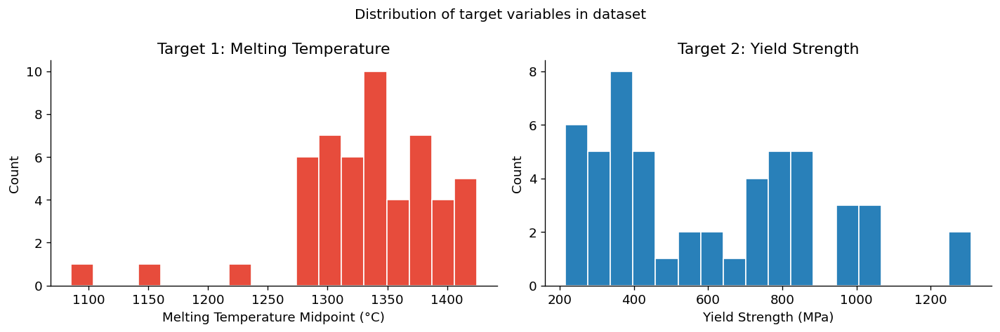

In [24]:
# ── Step 2e: Visualize the two target variable (yield strength and melting point) distributions ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Remove NaN values before plotting using dropna()
melting_temp_clean = df["Melting Temperature Mid (C)"].dropna()
yield_strength_clean = df["Yield Strength (MPa)"].dropna()

axes[0].hist(melting_temp_clean, bins=18,
             color="#e74c3c", edgecolor="white")
axes[0].set_xlabel("Melting Temperature Midpoint (°C)")
axes[0].set_ylabel("Count")
axes[0].set_title("Target 1: Melting Temperature")

axes[1].hist(yield_strength_clean, bins=18,
             color="#2980b9", edgecolor="white")
axes[1].set_xlabel("Yield Strength (MPa)")
axes[1].set_ylabel("Count")
axes[1].set_title("Target 2: Yield Strength")

plt.suptitle("Distribution of target variables in dataset", fontsize=12)
plt.tight_layout()
plt.show()

### 3. Feature Preparation

Often when handling data, values need to be appropriately scaled so that disparate entries can be compared to one another. In this case, our features are the 14 elemental composition columns (wt%). Before feeding them
into a GP model we apply **StandardScaler** to give each element zero mean and
unit variance.

Unlike other AI-bases analysis methods like K-means, which enables clustering, GP regression is less sensitive to
scale differences, but scaling still helps the kernel hyperparameter optimizer
converge reliably, and it makes the learned length-scales interpretable. In other words, a large length-scale for an element means the model thinks that element
has a weak or strong influence on the target.


In [25]:
# ── Define feature columns and targets ───────────────────────────────────────

FEATURE_COLS = [
    "Al wt%", "C wt%", "Co wt%", "Cr wt%", "Cu wt%",
    "Fe wt%", "Mn wt%", "Mo wt%", "Nb wt%", "Ni wt%",
    "Ta wt%", "Ti wt%", "W wt%", "Other",
]

TARGET_MELT  = "Melting Temperature Mid (C)"
TARGET_YIELD = "Yield Strength (MPa)"

X = df[FEATURE_COLS].values
y_melt  = df[TARGET_MELT].values
y_yield = df[TARGET_YIELD].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Melting temperature range: {y_melt.min():.0f} – {y_melt.max():.0f} °C")
print(f"Yield strength range:      {y_yield.min():.0f} – {y_yield.max():.0f} MPa")


Feature matrix shape: (52, 14)
Melting temperature range: 1085 – 1425 °C
Yield strength range:      215 – 1310 MPa


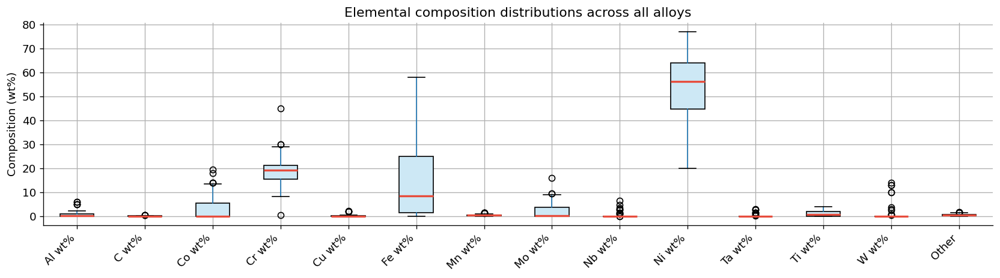

In [26]:
# ── Visualize elemental composition spread ────────────────────────────────────
#
# Box plots show how much each element varies across the dataset.
# Elements with near-zero variance carry little information for the model.

fig, ax = plt.subplots(figsize=(14, 4))
df[FEATURE_COLS].boxplot(ax=ax, patch_artist=True,
                          boxprops=dict(facecolor="#cde8f5"),
                          medianprops=dict(color="#e74c3c", linewidth=2))
ax.set_ylabel("Composition (wt%)")
ax.set_title("Elemental composition distributions across all alloys")
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 4. Introduction to Gaussian Process Regression

To recap, a **Gaussian Process (GP)** is a probabilistic model that treats the unknown function
mapping composition → property as a distribution over functions.
Rather than predicting a single number, a GP predicts a **mean** *and* a
**standard deviation** (uncertainty) at every point in composition space.

This is a critical advantage over simpler models for materials discovery:
- In regions **close to training data**, uncertainty is low → predictions are trustworthy.
- In regions **far from training data**, uncertainty is high → the model honestly
  tells you it does not know, rather than giving a confident but wrong answer.

The **kernel function** encodes our prior belief about the smoothness of the
property landscape. We use a **Radial Basis Function (RBF)** kernel:

$$k(x_i, x_j) = \sigma^2 \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\ell^2}\right)$$

- $\sigma^2$ (amplitude): overall variance of the function
- $\ell$ (length-scale): how far apart two compositions must be before their
  property values become uncorrelated. A large $\ell$ means the property
  varies slowly and smoothly with composition.

We also add a **WhiteKernel** to account for noise (measurement error,
processing variation between alloys with the same composition).

> Think of the GP as a very sophisticated interpolation: it fits a smooth surface
> through the data points and tells you how confident it is between them.


### 5. Train GP Models and Evaluate with Leave-One-Out Cross-Validation

With only ~50 data points, a standard train/test split would waste too much data.
We use **Leave-One-Out Cross-Validation (LOO-CV)**:
train on 49 alloys, predict the 1 held-out alloy, repeat for all 50 alloys.
This gives us an honest estimate of how well the model generalises to unseen compositions.


In [27]:
# ── Define kernel and GP model ────────────────────────────────────────────────
#
# ConstantKernel * RBF  — captures smooth composition-property relationships
# WhiteKernel           — captures noise / processing variability
#
# n_restarts_optimizer=10 runs the hyperparameter optimiser from 10 random
# starting points to reduce the risk of getting stuck in a local optimum.

def make_gp():
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42,
    )

print("GP model definition ✓")
print(f"Kernel: {make_gp().kernel}")


GP model definition ✓
Kernel: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)


In [28]:
# ── LOO-CV for melting temperature ────────────────────────────────────────────

loo = LeaveOneOut()

y_melt_pred = cross_val_predict(make_gp(), X_scaled, y_melt, cv=loo)

r2_melt  = r2_score(y_melt, y_melt_pred)
mae_melt = mean_absolute_error(y_melt, y_melt_pred)

print(f"Melting Temperature  |  LOO R² = {r2_melt:.3f}  |  LOO MAE = {mae_melt:.1f} °C")


Melting Temperature  |  LOO R² = 0.021  |  LOO MAE = 30.0 °C


In [31]:
# ── LOO-CV for yield strength ─────────────────────────────────────────────────

y_yield_pred = cross_val_predict(make_gp(), X_scaled, y_yield, cv=loo)

r2_yield  = r2_score(y_yield, y_yield_pred)
mae_yield = mean_absolute_error(y_yield, y_yield_pred)

print(f"Yield Strength       |  LOO R² = {r2_yield:.3f}  |  LOO MAE = {mae_yield:.1f} MPa")


Yield Strength       |  LOO R² = 0.721  |  LOO MAE = 111.0 MPa


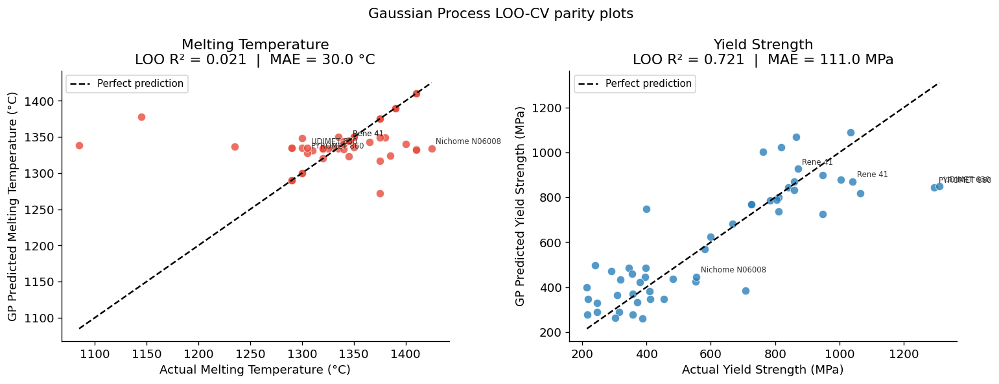

In [32]:
# ── Parity plots: predicted vs. actual ───────────────────────────────────────
#
# A good model hugs the diagonal (y = x). Scatter around the diagonal
# represents prediction error. Points far from the diagonal are
# compositions the model struggled with — worth investigating why.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, label, units, color, r2, mae in [
    (axes[0], y_melt,  y_melt_pred,  "Melting Temperature", "°C",  "#e74c3c", r2_melt,  mae_melt),
    (axes[1], y_yield, y_yield_pred, "Yield Strength",      "MPa", "#2980b9", r2_yield, mae_yield),
]:
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="Perfect prediction")
    ax.scatter(y_true, y_pred, c=color, s=55, alpha=0.8,
               edgecolors="white", linewidths=0.5)

    # Annotate a few alloys by name
    for i, name in enumerate(df["Material Name"]):
        if any(tag in name for tag in ["PYROMET", "UDIMET", "Rene 41", "Nichome"]):
            ax.annotate(name.split(",")[0], (y_true[i], y_pred[i]),
                        fontsize=7, xytext=(4, 4), textcoords="offset points",
                        color="#333333")

    ax.set_xlabel(f"Actual {label} ({units})")
    ax.set_ylabel(f"GP Predicted {label} ({units})")
    ax.set_title(f"{label}\nLOO R² = {r2:.3f}  |  MAE = {mae:.1f} {units}")
    ax.legend(fontsize=9)

plt.suptitle("Gaussian Process LOO-CV parity plots", fontsize=13)
plt.tight_layout()
plt.show()


### 6. Fit Final Models on Full Dataset and Inspect Uncertainty

Now we fit both GP models on the **entire dataset** — not for cross-validation,
but to get the best possible surrogate models for composition space exploration.

The GP's uncertainty estimates (posterior standard deviation) tell us:
- **Low σ near training data**: we have seen compositions like this before;
  the prediction is reliable.
- **High σ far from training data**: the model is extrapolating;
  any prediction here should be treated with caution.


In [33]:
# ── Fit final GP models ───────────────────────────────────────────────────────

gp_melt  = make_gp()
gp_yield = make_gp()

gp_melt.fit(X_scaled, y_melt)
gp_yield.fit(X_scaled, y_yield)

print("=" * 60)
print("Optimised kernel — Melting Temperature:")
print(f"  {gp_melt.kernel_}")
print()
print("Optimised kernel — Yield Strength:")
print(f"  {gp_yield.kernel_}")


Optimised kernel — Melting Temperature:
  1.06**2 * RBF(length_scale=0.956) + WhiteKernel(noise_level=1e-05)

Optimised kernel — Yield Strength:
  1.18**2 * RBF(length_scale=5.36) + WhiteKernel(noise_level=0.166)


In [34]:
# ── Uncertainty on the training data ─────────────────────────────────────────
#
# Even at training points, some uncertainty remains due to the WhiteKernel
# (noise term). This reflects genuine variability between alloys with
# the same composition but different processing histories.

mu_melt,  sigma_melt  = gp_melt.predict(X_scaled,  return_std=True)
mu_yield, sigma_yield = gp_yield.predict(X_scaled, return_std=True)

df["GP_Melt_Predicted"]      = mu_melt
df["GP_Melt_Uncertainty"]    = sigma_melt
df["GP_Yield_Predicted"]     = mu_yield
df["GP_Yield_Uncertainty"]   = sigma_yield

print("Prediction uncertainties (posterior σ) on training data:")
print(f"  Melting temperature: mean σ = {sigma_melt.mean():.1f} °C,  "
      f"max σ = {sigma_melt.max():.1f} °C")
print(f"  Yield strength:      mean σ = {sigma_yield.mean():.1f} MPa,  "
      f"max σ = {sigma_yield.max():.1f} MPa")


Prediction uncertainties (posterior σ) on training data:
  Melting temperature: mean σ = 0.3 °C,  max σ = 0.3 °C
  Yield strength:      mean σ = 140.3 MPa,  max σ = 159.5 MPa


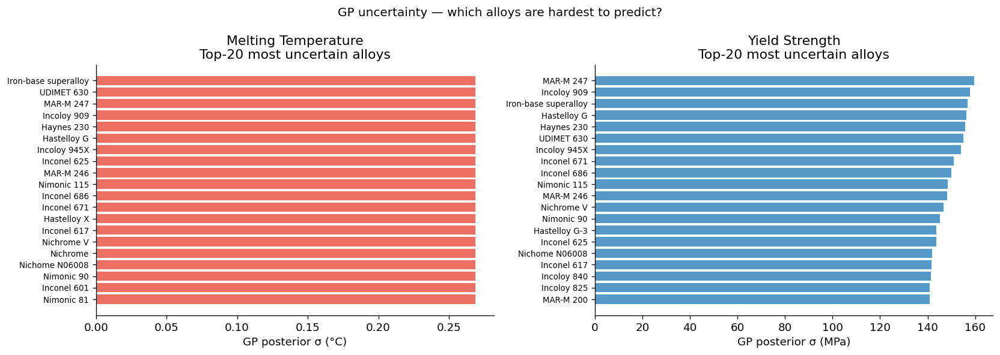

In [35]:
# ── Uncertainty bar chart: which alloys does the model know least about? ──────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sigma, label, units, color in [
    (axes[0], sigma_melt,  "Melting Temperature", "°C",  "#e74c3c"),
    (axes[1], sigma_yield, "Yield Strength",      "MPa", "#2980b9"),
]:
    idx_sorted = np.argsort(sigma)[::-1][:20]  # top-20 most uncertain
    names = [df.loc[i, "Material Name"].split(",")[0] for i in idx_sorted]
    ax.barh(range(len(names)), sigma[idx_sorted], color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel(f"GP posterior σ ({units})")
    ax.set_title(f"{label}\nTop-20 most uncertain alloys")
    ax.invert_yaxis()

plt.suptitle("GP uncertainty — which alloys are hardest to predict?", fontsize=12)
plt.tight_layout()
plt.show()


### 7. Feature Importance via GP Length-Scales

The RBF kernel has one length-scale per feature (when using an ARD — Automatic
Relevance Determination — variant). Here we use a single shared length-scale,
but we can still get a proxy for feature importance by measuring how much
the model's predictions change when we individually permute each element.

This is called **Permutation Feature Importance**: shuffle one column at a time,
recompute predictions, and measure how much worse the model gets.
A large drop in performance → that element matters a lot.


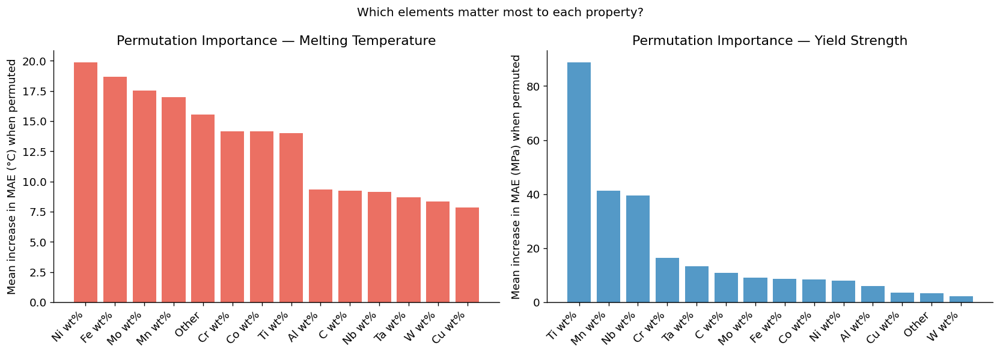

In [36]:
# ── Permutation feature importance ────────────────────────────────────────────

rng = np.random.default_rng(42)

def permutation_importance(gp_model, X_sc, y_true, n_repeats=30):
    baseline_mae = mean_absolute_error(y_true, gp_model.predict(X_sc))
    importances = []
    for col_idx in range(X_sc.shape[1]):
        delta_maes = []
        for _ in range(n_repeats):
            X_perm = X_sc.copy()
            rng.shuffle(X_perm[:, col_idx])
            perm_mae = mean_absolute_error(y_true, gp_model.predict(X_perm))
            delta_maes.append(perm_mae - baseline_mae)
        importances.append(np.mean(delta_maes))
    return np.array(importances)

imp_melt  = permutation_importance(gp_melt,  X_scaled, y_melt)
imp_yield = permutation_importance(gp_yield, X_scaled, y_yield)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, label, units, color in [
    (axes[0], imp_melt,  "Melting Temperature", "°C",  "#e74c3c"),
    (axes[1], imp_yield, "Yield Strength",      "MPa", "#2980b9"),
]:
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(FEATURE_COLS)), imp[idx], color=color, alpha=0.8)
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels([FEATURE_COLS[i] for i in idx], rotation=45, ha="right")
    ax.set_ylabel(f"Mean increase in MAE ({units}) when permuted")
    ax.set_title(f"Permutation Importance — {label}")
    ax.axhline(0, color="black", linewidth=0.8)

plt.suptitle("Which elements matter most to each property?", fontsize=12)
plt.tight_layout()
plt.show()


### Discussion Questions — Part I

1. **Model quality**: Look at your LOO-CV parity plots (Section 5).  
   Which property does the GP predict more accurately: melting temperature or yield strength?  
   What physical reason might explain this difference?

2. **Uncertainty**: Which alloys have the highest GP uncertainty in yield strength?  
   Look at their compositions (Section 3). What do they have in common that might
   make them hard to predict?

3. **Feature importance**: Which two or three elements have the largest permutation
   importance for melting temperature? Does this match your physical intuition
   about which elements raise or lower a superalloy's melting point?

4. **Noise kernel**: The GP includes a WhiteKernel to model noise. Several alloys
   in the dataset have *identical compositions* but different yield strengths
   (e.g., Inconel 600 annealed vs. cold worked vs. hard). How does this affect
   what the noise term is actually capturing?


### 8. Composition Space Search with Expected Improvement

Now we turn from *prediction* to *discovery*: using the GP models to intelligently
search for new alloy compositions that maximise both melting temperature and yield strength.

#### Strategy: Expected Improvement (EI)

A naive approach would be to predict the property at a large number of candidate
compositions and pick the one with the highest predicted mean. But this ignores
uncertainty — a composition with a high mean but low uncertainty is less interesting
than one with a slightly lower mean but much higher uncertainty (it might be even better
than predicted once we measure it).

**Expected Improvement (EI)** balances exploitation (go where predicted values are high)
with exploration (go where uncertainty is high):

$$\mathrm{EI}(x) = (\mu(x) - y^*) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z)$$

where $Z = (\mu(x) - y^*) / \sigma(x)$, $y^*$ is the current best observed value,
and $\Phi$, $\phi$ are the normal CDF and PDF.

> EI is the key acquisition function in **Bayesian Optimization** — the framework
> that powers modern AI-assisted materials discovery pipelines.


In [38]:
# ── Expected Improvement function ─────────────────────────────────────────────

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Compute Expected Improvement acquisition function.

    Parameters
    ----------
    mu     : predicted mean (array)
    sigma  : predicted std dev (array)
    y_best : best observed value so far (scalar)
    xi     : exploration-exploitation trade-off parameter (default 0.01)
             Larger xi → more exploration of uncertain regions.

    Returns
    -------
    EI values (array, same shape as mu)
    """
    improvement = mu - y_best - xi
    Z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0  # no improvement possible with zero uncertainty
    return ei

print("EI function defined ✓")


EI function defined ✓


In [39]:
# ── Generate a random candidate set ──────────────────────────────────────────
#
# We sample 5000 random compositions from a physically plausible space.
# Each candidate is a random draw from the observed compositional ranges.
# Compositions are normalised to sum to 100 wt%.
#
# In a real discovery campaign, you would use more principled sampling
# (e.g., Latin hypercube or CALPHAD-constrained compositions).

N_CANDIDATES = 5000
rng = np.random.default_rng(0)

# Sample from uniform distributions bounded by observed min/max for each element
col_mins = df[FEATURE_COLS].min().values
col_maxs = df[FEATURE_COLS].max().values

C_raw = rng.uniform(low=col_mins, high=col_maxs, size=(N_CANDIDATES, len(FEATURE_COLS)))

# Renormalise each row to sum to 100 wt%
C_raw = C_raw / C_raw.sum(axis=1, keepdims=True) * 100

C_scaled = scaler.transform(C_raw)

print(f"Generated {N_CANDIDATES} candidate compositions")
print(f"Composition sum check — mean: {C_raw.sum(axis=1).mean():.2f} wt%  "
      f"(should be 100)")


Generated 5000 candidate compositions
Composition sum check — mean: 100.00 wt%  (should be 100)


In [40]:
# ── Predict on candidates and compute EI ──────────────────────────────────────

mu_melt_c,  sigma_melt_c  = gp_melt.predict(C_scaled,  return_std=True)
mu_yield_c, sigma_yield_c = gp_yield.predict(C_scaled, return_std=True)

# Current best observed values
best_melt  = y_melt.max()
best_yield = y_yield.max()

print(f"Best observed melting temperature: {best_melt:.0f} °C")
print(f"Best observed yield strength:      {best_yield:.0f} MPa")

# Compute EI for each target
ei_melt  = expected_improvement(mu_melt_c,  sigma_melt_c,  best_melt)
ei_yield = expected_improvement(mu_yield_c, sigma_yield_c, best_yield)

# Combined score: geometric mean of the two EI values
# (you could also weight them differently based on your design priorities)
ei_combined = np.sqrt(ei_melt * ei_yield)

print(f"\nMax EI (melting):   {ei_melt.max():.4f}")
print(f"Max EI (yield):     {ei_yield.max():.4f}")
print(f"Max EI (combined):  {ei_combined.max():.4f}")


Best observed melting temperature: 1425 °C
Best observed yield strength:      1310 MPa

Max EI (melting):   3.1245
Max EI (yield):     51.6323
Max EI (combined):  10.7211


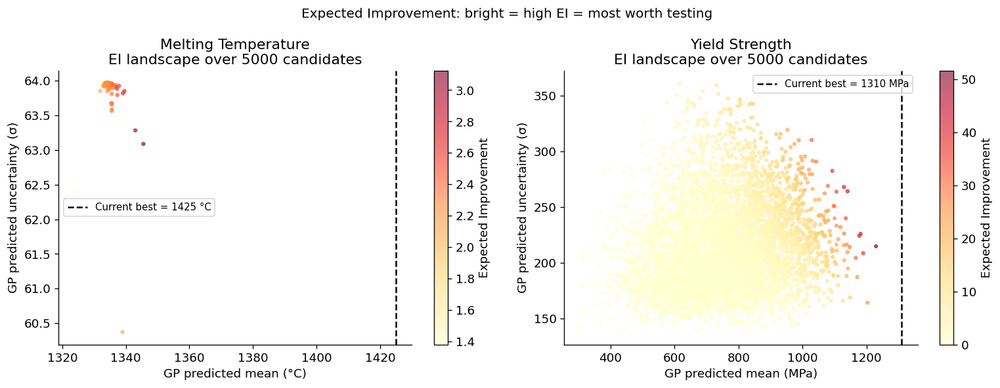

In [41]:
# ── Visualise the EI landscape: predicted mean vs. uncertainty ────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mu, sigma, ei, y_best, label, units, color in [
    (axes[0], mu_melt_c,  sigma_melt_c,  ei_melt,  best_melt,
     "Melting Temperature", "°C",  "#e74c3c"),
    (axes[1], mu_yield_c, sigma_yield_c, ei_yield, best_yield,
     "Yield Strength",      "MPa", "#2980b9"),
]:
    sc = ax.scatter(mu, sigma, c=ei, cmap="YlOrRd", s=8, alpha=0.6)
    ax.axvline(y_best, color="black", linewidth=1.5, linestyle="--",
               label=f"Current best = {y_best:.0f} {units}")
    plt.colorbar(sc, ax=ax, label="Expected Improvement")
    ax.set_xlabel(f"GP predicted mean ({units})")
    ax.set_ylabel("GP predicted uncertainty (σ)")
    ax.set_title(f"{label}\nEI landscape over {N_CANDIDATES} candidates")
    ax.legend(fontsize=9)

plt.suptitle("Expected Improvement: bright = high EI = most worth testing",
             fontsize=12)
plt.tight_layout()
plt.show()


### 9. Top Candidate Compositions

We rank all 5,000 candidates by their combined EI score and report the top 10.
These are the compositions the model considers most worth testing experimentally:
they are predicted to outperform anything in our training set, and the GP
has meaningful confidence in that prediction.


In [42]:
# ── Rank candidates and display top 10 ───────────────────────────────────────

candidates_df = pd.DataFrame(C_raw, columns=FEATURE_COLS)
candidates_df["Predicted Melt (°C)"]     = mu_melt_c
candidates_df["Melt Uncertainty (°C)"]   = sigma_melt_c
candidates_df["Predicted Yield (MPa)"]   = mu_yield_c
candidates_df["Yield Uncertainty (MPa)"] = sigma_yield_c
candidates_df["EI Melt"]                 = ei_melt
candidates_df["EI Yield"]                = ei_yield
candidates_df["EI Combined"]             = ei_combined

top10 = (
    candidates_df
    .sort_values("EI Combined", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display_cols = [
    "Ni wt%", "Cr wt%", "Co wt%", "Fe wt%", "Mo wt%", "Ti wt%", "Al wt%", "W wt%",
    "Predicted Melt (°C)", "Melt Uncertainty (°C)",
    "Predicted Yield (MPa)", "Yield Uncertainty (MPa)",
    "EI Combined",
]

print("Top 10 candidate compositions by combined Expected Improvement:")
display(top10[display_cols].round(2))


Top 10 candidate compositions by combined Expected Improvement:


,Ni wt%,Cr wt%,Co wt%,Fe wt%,Mo wt%,Ti wt%,Al wt%,W wt%,Predicted Melt (°C),Melt Uncertainty (°C),Predicted Yield (MPa),Yield Uncertainty (MPa),EI Combined
0,56.99,3.78,6.55,10.41,5.60,3.36,1.04,4.89,1333.94,63.97,1230.06,214.93,10.72
1,45.11,4.27,7.30,15.25,8.25,3.09,5.16,1.82,1333.94,63.97,1141.08,264.28,9.65
2,53.36,6.96,3.55,10.98,5.40,2.69,1.83,6.62,1333.94,63.97,1181.89,226.11,9.47
3,29.95,13.48,6.29,17.88,8.66,3.07,0.96,8.58,1333.94,63.97,1129.69,268.12,9.45
4,49.05,4.70,6.24,22.17,3.48,3.18,0.39,2.10,1333.94,63.97,1177.55,224.28,9.25
5,32.26,3.20,11.09,32.49,9.24,2.64,0.64,1.57,1334.01,63.97,1189.94,208.71,9.04
6,27.49,1.51,9.89,35.73,5.58,3.89,4.46,0.94,1333.94,63.97,1093.34,282.59,8.95
7,20.41,2.93,4.83,54.37,1.50,3.81,3.74,0.18,1333.94,63.97,1106.30,264.00,8.62
8,25.55,5.15,2.29,36.58,6.96,2.60,3.07,11.09,1333.94,63.97,1135.72,239.99,8.54
9,28.41,6.90,4.12,25.76,2.50,4.08,2.06,13.42,1333.94,63.97,1028.84,310.29,8.28


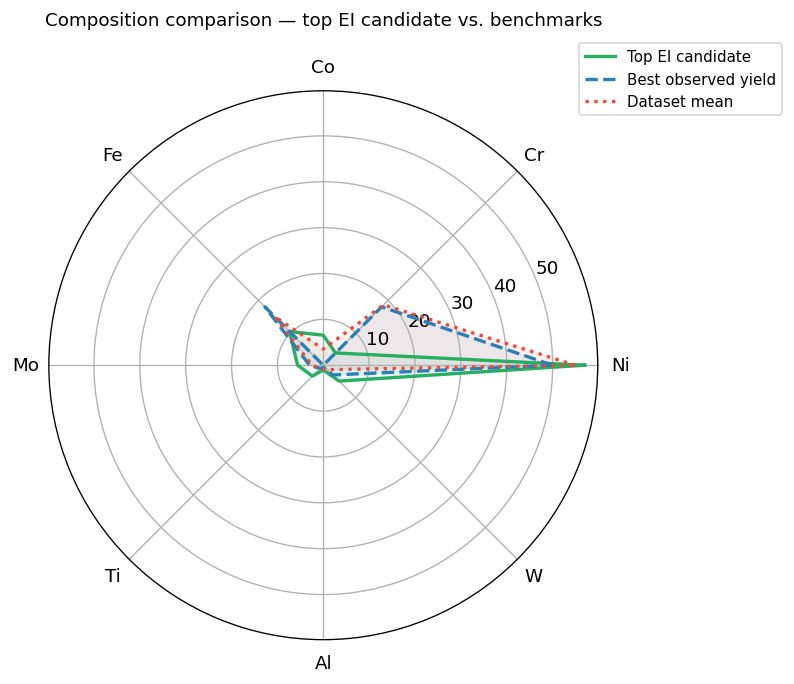


Top EI candidate predictions:
  Melting temperature: 1334 ± 64 °C
  Yield strength:      1230 ± 215 MPa


In [43]:
# ── Radar / spider chart for the top candidate ────────────────────────────────
#
# Compare the top EI candidate composition against the dataset mean
# and the alloy with the highest observed yield strength.

elements_to_plot = ["Ni wt%", "Cr wt%", "Co wt%", "Fe wt%",
                    "Mo wt%", "Ti wt%", "Al wt%", "W wt%"]

top1 = top10.iloc[0]
best_yield_alloy = df.loc[df["Yield Strength (MPa)"].idxmax()]
dataset_mean = df[elements_to_plot].mean()

angles = np.linspace(0, 2 * np.pi, len(elements_to_plot), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for values, label, color, ls in [
    (top1[elements_to_plot].values,              "Top EI candidate",       "#27ae60", "-"),
    (best_yield_alloy[elements_to_plot].values,  "Best observed yield",    "#2980b9", "--"),
    (dataset_mean.values,                         "Dataset mean",           "#e74c3c", ":"),
]:
    vals = np.concatenate([values, [values[0]]])
    ax.plot(angles, vals, linestyle=ls, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([e.replace(" wt%", "") for e in elements_to_plot], fontsize=11)
ax.set_title("Composition comparison — top EI candidate vs. benchmarks",
             fontsize=11, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nTop EI candidate predictions:")
print(f"  Melting temperature: {top1['Predicted Melt (°C)']:.0f} ± {top1['Melt Uncertainty (°C)']:.0f} °C")
print(f"  Yield strength:      {top1['Predicted Yield (MPa)']:.0f} ± {top1['Yield Uncertainty (MPa)']:.0f} MPa")


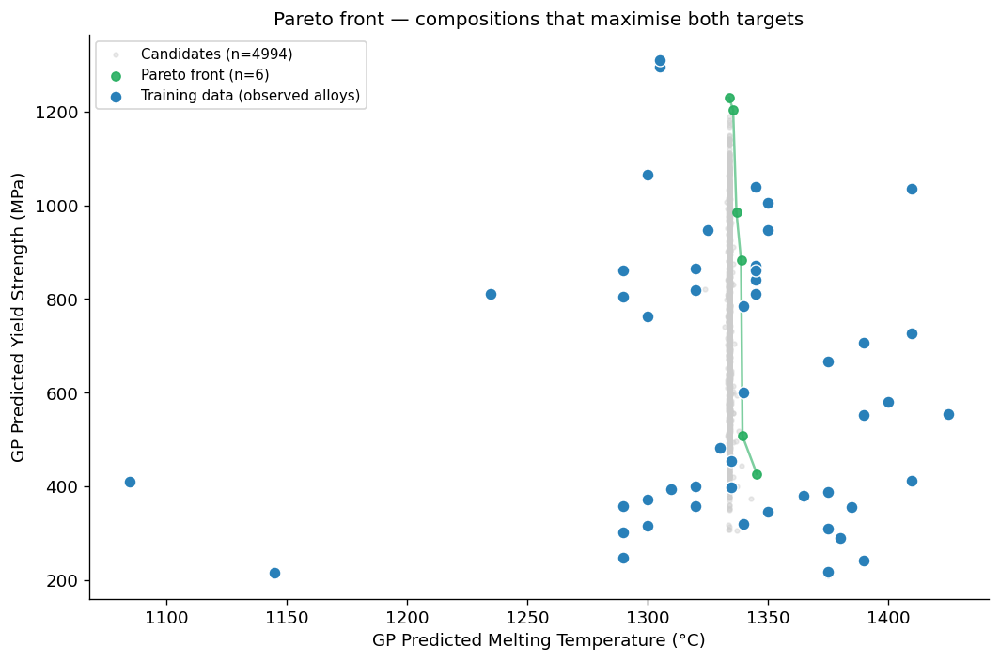

In [44]:
# ── Pareto front: melting temperature vs. yield strength ──────────────────────
#
# Not every high-EI candidate will maximise both targets simultaneously.
# The Pareto front shows the set of compositions where you cannot improve
# one target without sacrificing the other — the optimal trade-off boundary.

def is_pareto(costs):
    """Return boolean mask of Pareto-optimal points (maximisation)."""
    n = costs.shape[0]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (costs[j] >= costs[i]).all() and (costs[j] > costs[i]).any():
                dominated[i] = True
                break
    return ~dominated

# Use predicted means on candidates as objective values
objectives = np.column_stack([mu_melt_c, mu_yield_c])
pareto_mask = is_pareto(objectives)

fig, ax = plt.subplots(figsize=(9, 6))

# All candidates (grey)
ax.scatter(mu_melt_c[~pareto_mask], mu_yield_c[~pareto_mask],
           c="#cccccc", s=8, alpha=0.4, label=f"Candidates (n={(~pareto_mask).sum()})")

# Pareto-optimal candidates (green)
pareto_idx = np.where(pareto_mask)[0]
pareto_sorted = pareto_idx[np.argsort(mu_melt_c[pareto_idx])]
ax.scatter(mu_melt_c[pareto_mask], mu_yield_c[pareto_mask],
           c="#27ae60", s=30, alpha=0.9, zorder=5,
           label=f"Pareto front (n={pareto_mask.sum()})")
ax.plot(mu_melt_c[pareto_sorted], mu_yield_c[pareto_sorted],
        color="#27ae60", linewidth=1.5, alpha=0.6)

# Training data (blue)
ax.scatter(y_melt, y_yield, c="#2980b9", s=60, zorder=10,
           edgecolors="white", linewidths=0.8,
           label="Training data (observed alloys)")

ax.set_xlabel("GP Predicted Melting Temperature (°C)")
ax.set_ylabel("GP Predicted Yield Strength (MPa)")
ax.set_title("Pareto front — compositions that maximise both targets", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Discussion Questions — Part II

1. **EI intuition**: Look at the EI landscape scatter plots (Section 8).  
   Identify a point with **high predicted mean but low EI**, and a point with
   **moderate predicted mean but high EI**. Why does the second point have higher EI
   despite a lower mean prediction?

2. **Top candidate chemistry**: Examine the composition of the top EI candidate
   (radar chart, Section 9). How does it differ from the dataset mean?  
   Does any element appear at an extreme value compared to the training data?
   What concern does this raise about the reliability of the GP prediction there?

3. **Pareto trade-off**: Look at the Pareto front plot. Is there a region of
   the front where a small sacrifice in yield strength buys a large gain in
   melting temperature, or vice versa? What does the shape of the front tell
   you about how these two properties are correlated in this alloy family?

4. **Exploration parameter**: The `xi` parameter in the EI function controls
   exploration vs. exploitation. Re-run the candidate search with `xi=0.0`
   (pure exploitation) and `xi=1.0` (heavy exploration).  
   How do the top candidates change? Which setting would you use if experimental
   tests were very expensive?

5. **Limits of the model**: The GP was trained on nickel-base superalloys.
   Can it reliably predict properties for a true high entropy alloy
   (e.g., CrMnFeCoNi in equimolar proportions)?  
   What would you need to do to make it applicable to HEAs?

6. **Active learning**: Bayesian optimization is iterative: after measuring
   the top candidate experimentally, you add it to the training set and
   refit the GP. How would you expect the Pareto front to evolve after
   five such iterations if the measurements confirm the GP's predictions?


---
## Summary

| Step | What we did | Why it matters |
|---|---|---|
| Data parsing | Split key:value text into a proper DataFrame | Raw file was not machine-readable |
| Outlier removal | Removed A-286 (melting range 632–705 °C) | Corrupted regression target |
| Midpoint target | Averaged Min/Max melting temperature | Single numeric target for regression |
| StandardScaler | Zero-mean, unit-variance elemental features | Stabilises GP kernel optimisation |
| GP with RBF kernel | Fit composition → property surface | Provides predictions *and* uncertainties |
| LOO-CV | Evaluated generalisation on 50-sample dataset | Honest estimate with limited data |
| Permutation importance | Identified key elements for each property | Connects ML to materials chemistry |
| Expected Improvement | Scored 5,000 candidate compositions | Balances exploitation and exploration |
| Pareto front | Mapped the melting vs. yield trade-off | Supports multi-objective design decisions |

**Key finding:** Gaussian Process regression provides not just predictions but *calibrated uncertainty*,
which is essential for guiding experiments in a large, unexplored composition space.
The Expected Improvement acquisition function operationalises this: it tells us
exactly which untested compositions are most worth measuring next —
the foundation of AI-accelerated materials discovery.


## Sources
1. P. Herrera-Siklody, “4.5 The Carnot Cycle,” Pressbooks, Aug. 2016. Accessed: July 23, 2026. [Online]. Available: https://pressbooks.online.ucf.edu/phy2048tjb/chapter/4-5-the-carnot-cycle/
2. American Elements, “Melting Points of Common Materials | Toolbox | AMERICAN ELEMENTS,” 2025. Accessed: July 23, 2026. [Online]. Available: https://www.americanelements.com/meltingpoint.html
3. Singh, J.B. (2022). Life Management of Alloy 625 Components. In: Alloy 625 . Materials Horizons: From Nature to Nanomaterials. Springer, Singapore. https://doi.org/10.1007/978-981-19-1562-8_8
4. “A Comprehensive Overview of Environmental Hydrogen Embrittlement - Mass Timber Connections (MTC) Solutions,” Jan. 2025. Accessed: July 24, 2026. [Online]. Available: https://mtcsolutions.com/resources/tech-blogs/a-comprehensive-overview-of-environmental-hydrogen-embrittlement/
5. M. C. Rezende, L. S. Araujo, S. B. Gabriel, D. S. dos Santos, and L. H. de Almeida, “Hydrogen embrittlement in nickel-based superalloy 718: Relationship between γ′ + γ″ precipitation and the fracture mode,” International Journal of Hydrogen Energy, vol. 40, no. 47, pp. 17075–17083, Dec. 2015. Accessed: Jul. 23, 2026. doi: 10.1016/j.ijhydene.2015.07.053. [Online]. Available: https://doi.org/10.1016/j.ijhydene.2015.07.053.
6. S. Choudhary and J. Zhang, “Study of additively manufactured Inconel 718 with lanthanum zirconate coating,” Journal of Alloys and Compounds, vol. 1201, 5 April 2025. Accessed: Jul. 23, 2026. doi: 10.1016/j.jallcom.2025.179710. [Online]. Available: https://doi.org/10.1016/j.jallcom.2025.179710.
7. N. Kaewchoothong, K. Maliwan, K. Takeishi, C. Nuntadusit, "Effect of inclined ribs on heat transfer coefficient in stationary square channel," Theoretical and Applied Mechanics Letters, vol. 7, no. 6, 344-350, Nov. 2017. Accessed: Jul. 23, 2026. doi: 10.1016/j.taml.2017.09.013. [Online]. Available: https://doi.org/10.1016/j.taml.2017.09.013
8. E. P. George, D. Raabe, and R. O. Ritchie, “High‑entropy alloys,” Nature Reviews Materials, vol. 4, pp. 515–534, Jun. 2019. Accessed: Jul. 23, 2026. doi: 10.1038/s41578‑019‑0121‑4. [Online]. Available: https://doi.org/10.1038/s41578‑019‑0121‑4
9. E. Kavlakoglu and V. Winland, “What is k-means clustering?,” June 2024. Accessed: July 22, 2026. [Online]. Available: https://www.ibm.com/think/topics/k-means-clustering
10. J. Wang, “An Intuitive Tutorial to Gaussian Process Regression.” Accessed: Aug. 10, 2026. [Online]. Available: https://arxiv.org/html/2009.10862v5